## 1. Setup e Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from tqdm import tqdm
import os
import sys
from pathlib import Path

# Agregar path del proyecto para imports
sys.path.append(os.path.abspath('../../..'))
from sae.models.sae import SparseAutoencoder
from sae.models.naming_utils import save_checkpoint

# Configuración de visualización para Quarto/PDF
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', None)
np.set_printoptions(linewidth=100, precision=4)
os.environ['COLUMNS'] = '100'

# Configuración de reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print config con formato profesional
config_df = pd.DataFrame({
    'Configuración': ['Device', 'Seed', 'Output Width'],
    'Valor': [str(device), '42', '100']
})

print('\n' + '='*50)
print(' CONFIGURACIÓN INICIAL')
print('='*50)
print(config_df.to_string(index=False))
print('='*50)


 CONFIGURACIÓN INICIAL
Configuración Valor
       Device  cuda
         Seed    42
 Output Width   100


## 2.1 Metadata para Naming de Checkpoints

In [3]:
# Metadata para naming de checkpoints (separada de hiperparámetros)
NAMING_META = {
    'variante': 'standard',          # Arquitectura del SAE
    'tecnica': 'L1',     # L1 con penalty annealing
    'capa': 6,                       # Layer del modelo OthelloGPT
    'juegos': 1000,                  # Número de partidas
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\othello_hugging'  # Path base para organización
}

print('\n Metadata de naming:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata de naming:
  variante: standard
  tecnica: L1
  capa: 6
  juegos: 1000
  base_path: C:\Users\Esposa\Documents\Repos\othello_hugging


## 2. Configuración del SAE

**Nota:** Las activaciones ya fueron extraídas previamente con `run_extraction.py`.  
Aquí solo especificamos qué archivo cargar y los hiperparámetros del SAE.

In [4]:
# Configuración centralizada del SAE
CONFIG = {
    # Arquitectura
    'input_dim': 512,
    'hidden_dim': 16384,
    'tied_weights': False,
    
    # Entrenamiento
    'batch_size': 128,
    'num_epochs': 30,
    'learning_rate': 1e-3,
    'sparsity_coef': 5e-4,
    'sparsity_decay': 0.95,
    
    # Early Stopping
    'early_stopping': True,
    'patience': 5,
    
    # Datos
    'activations_file': Path('../../../activations/data/layer5_1000games.npy'),
    'save_dir': Path('./saved_model'),
    'plots_dir': Path('./plots')
}

# Crear directorios
CONFIG['save_dir'].mkdir(parents=True, exist_ok=True)
CONFIG['plots_dir'].mkdir(parents=True, exist_ok=True)

# Mostrar configuración con formato profesional
config_data = {
    'Categoría': [],
    'Parámetro': [],
    'Valor': []
}

# Arquitectura
for key in ['input_dim', 'hidden_dim', 'tied_weights']:
    config_data['Categoría'].append('Arquitectura')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

# Entrenamiento
for key in ['batch_size', 'num_epochs', 'learning_rate', 'sparsity_coef', 'sparsity_decay']:
    config_data['Categoría'].append('Entrenamiento')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

# Early Stopping
for key in ['early_stopping', 'patience']:
    config_data['Categoría'].append('Early Stopping')
    config_data['Parámetro'].append(key)
    config_data['Valor'].append(str(CONFIG[key]))

config_table = pd.DataFrame(config_data)

print('\n' + '='*70)
print(' CONFIGURACIÓN DEL SAE')
print('='*70)
print(config_table.to_string(index=False))
print('='*70)

print(f'\nArchivo de activaciones: {CONFIG["activations_file"]}')
print(f'Expansión: {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x')
print('='*70)


 CONFIGURACIÓN DEL SAE
     Categoría      Parámetro  Valor
  Arquitectura      input_dim    512
  Arquitectura     hidden_dim  16384
  Arquitectura   tied_weights  False
 Entrenamiento     batch_size    128
 Entrenamiento     num_epochs     30
 Entrenamiento  learning_rate  0.001
 Entrenamiento  sparsity_coef 0.0005
 Entrenamiento sparsity_decay   0.95
Early Stopping early_stopping   True
Early Stopping       patience      5

Archivo de activaciones: ..\..\..\activations\data\layer5_1000games.npy
Expansión: 32.0x


## 3. Dataset de Activaciones (Train/Validation Split 80-20%)

In [4]:
class ActivationsDataset(Dataset):
    """Dataset para cargar activaciones extraídas"""
    
    def __init__(self, activations_path):
        self.activations = np.load(activations_path)
    
    def __len__(self):
        return len(self.activations)
    
    def __getitem__(self, idx):
        return torch.tensor(self.activations[idx], dtype=torch.float32)

# Cargar dataset completo
full_dataset = ActivationsDataset(CONFIG['activations_file'])

# Información del dataset con formato profesional
dataset_info = pd.DataFrame({
    'Propiedad': ['Total muestras', 'Shape', 'Dtype', 'Tamaño en memoria'],
    'Valor': [
        f"{len(full_dataset):,}",
        str(full_dataset.activations.shape),
        str(full_dataset.activations.dtype),
        f"{full_dataset.activations.nbytes / 1024**2:.2f} MB"
    ]
})
print('\n' + '='*50)
print(' DATASET DE ACTIVACIONES')
print('='*50)
print(dataset_info.to_string(index=False))
print('='*50)

# Split train/validation (80-20)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Resumen del split con formato profesional
split_info = pd.DataFrame({
    'Conjunto': ['Train', 'Validation', 'Total'],
    'Muestras': [
        f"{len(train_dataset):,}",
        f"{len(val_dataset):,}",
        f"{len(full_dataset):,}"
    ],
    'Porcentaje': [
        f"{len(train_dataset)/len(full_dataset):.1%}",
        f"{len(val_dataset)/len(full_dataset):.1%}",
        "100.0%"
    ]
})
print('\n' + '='*50)
print(' SPLIT DE DATOS (80-20)')
print('='*50)
print(split_info.to_string(index=False))
print('='*50)

# Crear DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,  # No shuffle para validación
    num_workers=0,
    pin_memory=(device.type == 'cuda')
)

# Resumen de DataLoaders
loader_info = pd.DataFrame({
    'DataLoader': ['Train', 'Validation'],
    'Batches': [len(train_loader), len(val_loader)],
    'Batch Size': [CONFIG['batch_size'], CONFIG['batch_size']],
    'Shuffle': ['Sí', 'No']
})

print('\n' + '='*50)
print(' DATALOADERS')
print('='*50)
print(loader_info.to_string(index=False))
print('='*50)


 DATASET DE ACTIVACIONES
        Propiedad        Valor
   Total muestras       59,000
            Shape (59000, 512)
            Dtype      float32
Tamaño en memoria    115.23 MB

 SPLIT DE DATOS (80-20)
  Conjunto Muestras Porcentaje
     Train   47,200      80.0%
Validation   11,800      20.0%
     Total   59,000     100.0%

 DATALOADERS
DataLoader  Batches  Batch Size Shuffle
     Train      369         128      Sí
Validation       93         128      No


## 4. Modelo: Sparse Autoencoder

Modelo importado desde `sae.models.sae.SparseAutoencoder`

**Arquitectura:**

- **Encoder**: Linear → ReLU (sparsity natural)- **Decoder**: Linear (reconstrucción)

In [5]:
# Crear modelo desde el módulo
model = SparseAutoencoder(
    input_dim=CONFIG['input_dim'],
    hidden_dim=CONFIG['hidden_dim'],
    tied_weights=CONFIG['tied_weights']
).to(device)

# Calcular parámetros
num_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in model.encoder.parameters())
if CONFIG['tied_weights']:
    decoder_params = CONFIG['input_dim']  # Solo bias
else:
    decoder_params = sum(p.numel() for p in model.decoder.parameters())

# Resumen del modelo con formato profesional
model_info = pd.DataFrame({
    'Componente': ['Input', 'Encoder', 'Hidden (Latent)', 'Decoder', 'Output', 'Total'],
    'Dimensión': [
        CONFIG['input_dim'],
        f"{CONFIG['input_dim']} → {CONFIG['hidden_dim']}",
        CONFIG['hidden_dim'],
        f"{CONFIG['hidden_dim']} → {CONFIG['input_dim']}",
        CONFIG['input_dim'],
        '-'
    ],
    'Parámetros': [
        '-',
        f"{encoder_params:,}",
        '-',
        f"{decoder_params:,}",
        '-',
        f"{num_params:,}"
    ]
})

print('\n' + '='*70)
print(' ARQUITECTURA DEL MODELO')
print('='*70)
print(model_info.to_string(index=False))
print('='*70)
print(f'\n Factor de expansión: {CONFIG["hidden_dim"]/CONFIG["input_dim"]:.1f}x')
print(f' Tied weights: {"Sí" if CONFIG["tied_weights"] else "No"}')
print(f' Device: {device}')
print('='*70)


 ARQUITECTURA DEL MODELO
     Componente   Dimensión Parámetros
          Input         512          -
        Encoder 512 → 16384  8,404,992
Hidden (Latent)       16384          -
        Decoder 16384 → 512  8,389,120
         Output         512          -
          Total           - 16,794,112

 Factor de expansión: 32.0x
 Tied weights: No
 Device: cuda


## 5. Función de Pérdida

**Loss = MSE(reconstrucción) + λ × L1(activaciones)**

- **MSE**: Mide qué tan bien reconstruimos las activaciones originales
- **L1**: Penaliza activaciones grandes → fuerza sparsity

In [6]:
def loss_function(x, reconstruction, hidden, sparsity_coef):
    """
    Pérdida compuesta: MSE + L1 penalty
    
    Args:
        x: Activaciones originales
        reconstruction: Activaciones reconstruidas
        hidden: Activaciones latentes (sparse)
        sparsity_coef: Peso de la penalización L1
    """
    # Error de reconstrucción
    mse_loss = F.mse_loss(reconstruction, x)
    
    # Sumar sobre las features (dim=1), promediar sobre el batch
    sparsity_loss = hidden.abs().sum(dim=1).mean()
    
    # Pérdida total
    total_loss = mse_loss + sparsity_coef * sparsity_loss
    
    return total_loss, mse_loss, sparsity_loss

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

# Resumen del optimizador
optim_info = pd.DataFrame({
    'Parámetro': ['Optimizador', 'Learning Rate', 'Sparsity Coef (inicial)', 'Sparsity Decay'],
    'Valor': [
        'Adam',
        f"{CONFIG['learning_rate']:.0e}",
        f"{CONFIG['sparsity_coef']:.0e}",
        f"{CONFIG['sparsity_decay']:.2f}"
    ]
})

print('\n' + '='*50)
print(' OPTIMIZACIÓN')
print('='*50)
print(optim_info.to_string(index=False))
print('='*50)


 OPTIMIZACIÓN
              Parámetro Valor
            Optimizador  Adam
          Learning Rate 1e-03
Sparsity Coef (inicial) 5e-04
         Sparsity Decay  0.95


## 6. Loop de Entrenamiento

In [7]:
# Historial de entrenamiento
history = {
    'train_total_loss': [],
    'train_mse_loss': [],
    'train_sparsity_loss': [],
    'train_l0_sparsity': [],
    'train_fraction_active': [],
    'val_total_loss': [],
    'val_mse_loss': [],
    'val_sparsity_loss': [],
    'val_l0_sparsity': [],
    'val_fraction_active': [],
    'sparsity_coef_history': []  # Guardar evolución del coeficiente L1
}

# Early stopping variables
best_val_mse = float('inf')
best_epoch = 0
epochs_no_improve = 0

print(f'\n Iniciando entrenamiento: {CONFIG["num_epochs"]} épocas máximo')
print(f' L1 decay: {CONFIG["sparsity_coef"]:.2e} × {CONFIG["sparsity_decay"]:.2f}^época')
print(f'⏸  Early stopping: patience={CONFIG["patience"]} épocas')
print('=' * 70)

for epoch in range(CONFIG['num_epochs']):
    # ========== L1 DECAY ==========
    # Reducir sparsity_coef exponencialmente
    current_sparsity_coef = CONFIG['sparsity_coef'] * (CONFIG['sparsity_decay'] ** epoch)
    history['sparsity_coef_history'].append(current_sparsity_coef)
    
    # ========== ENTRENAMIENTO ==========
    model.train()
    
    epoch_total_loss = 0
    epoch_mse_loss = 0
    epoch_sparsity_loss = 0
    epoch_l0 = 0
    epoch_fraction_active = 0
    
    # Barra de progreso
    pbar = tqdm(train_loader, desc=f'Época {epoch+1}/{CONFIG["num_epochs"]} [Train] L1={current_sparsity_coef:.2e}')
    
    for batch in pbar:
        # Mover al device
        x = batch.to(device)
        
        # Forward pass
        reconstruction, hidden = model(x)
        
        # Calcular pérdida con sparsity_coef actualizado
        total_loss, mse_loss, sparsity_loss = loss_function(
            x, reconstruction, hidden, current_sparsity_coef
        )
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        
        optimizer.step()
        
        # Métricas
        with torch.no_grad():
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()
        
        # Acumular
        epoch_total_loss += total_loss.item()
        epoch_mse_loss += mse_loss.item()
        epoch_sparsity_loss += sparsity_loss.item()
        epoch_l0 += l0
        epoch_fraction_active += fraction_active
        
        # Actualizar barra
        pbar.set_postfix({
            'loss': f'{total_loss.item():.4f}',
            'mse': f'{mse_loss.item():.4f}',
            'l0': f'{l0:.1f}'
        })
    
    # Promedios de entrenamiento
    num_train_batches = len(train_loader)
    avg_train_total_loss = epoch_total_loss / num_train_batches
    avg_train_mse_loss = epoch_mse_loss / num_train_batches
    avg_train_sparsity_loss = epoch_sparsity_loss / num_train_batches
    avg_train_l0 = epoch_l0 / num_train_batches
    avg_train_fraction_active = epoch_fraction_active / num_train_batches
    
    # ========== VALIDACIÓN ==========
    model.eval()
    
    val_total_loss = 0
    val_mse_loss = 0
    val_sparsity_loss = 0
    val_l0 = 0
    val_fraction_active = 0
    
    with torch.no_grad():
        for batch in val_loader:
            x = batch.to(device)
            
            # Forward pass
            reconstruction, hidden = model(x)
            
            # Calcular pérdida con sparsity_coef actualizado
            total_loss, mse_loss, sparsity_loss = loss_function(
                x, reconstruction, hidden, current_sparsity_coef
            )
            
            # Métricas
            l0 = (hidden > 0).float().sum(dim=1).mean().item()
            fraction_active = (hidden > 0).float().mean().item()
            
            # Acumular
            val_total_loss += total_loss.item()
            val_mse_loss += mse_loss.item()
            val_sparsity_loss += sparsity_loss.item()
            val_l0 += l0
            val_fraction_active += fraction_active
    
    # Promedios de validación
    num_val_batches = len(val_loader)
    avg_val_total_loss = val_total_loss / num_val_batches
    avg_val_mse_loss = val_mse_loss / num_val_batches
    avg_val_sparsity_loss = val_sparsity_loss / num_val_batches
    avg_val_l0 = val_l0 / num_val_batches
    avg_val_fraction_active = val_fraction_active / num_val_batches
    
    # Guardar en historial
    history['train_total_loss'].append(avg_train_total_loss)
    history['train_mse_loss'].append(avg_train_mse_loss)
    history['train_sparsity_loss'].append(avg_train_sparsity_loss)
    history['train_l0_sparsity'].append(avg_train_l0)
    history['train_fraction_active'].append(avg_train_fraction_active)
    
    history['val_total_loss'].append(avg_val_total_loss)
    history['val_mse_loss'].append(avg_val_mse_loss)
    history['val_sparsity_loss'].append(avg_val_sparsity_loss)
    history['val_l0_sparsity'].append(avg_val_l0)
    history['val_fraction_active'].append(avg_val_fraction_active)
    
    # ========== EARLY STOPPING ==========
    if CONFIG['early_stopping']:
        if avg_val_mse_loss < best_val_mse:
            best_val_mse = avg_val_mse_loss
            best_epoch = epoch + 1
            epochs_no_improve = 0
            
            # Guardar mejor modelo (local + organizado)
            best_checkpoint = {
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'config': CONFIG,
                'history': history,
                'epoch': best_epoch,
                'val_mse': best_val_mse
            }
            
            # Guardado local
            torch.save(best_checkpoint, os.path.join(CONFIG['save_dir'], 'sae_othello_best.pt'))
            
            # Guardado organizado
            save_checkpoint(
                model, 
                base_path=NAMING_META['base_path'],
                variante=NAMING_META['variante'],
                tecnica=NAMING_META['tecnica'],
                capa=NAMING_META['capa'],
                juegos=NAMING_META['juegos'],
                estado='best',
                config=CONFIG,
                history=history,
                optimizer=optimizer
            )
            
            print(f' Mejor modelo guardado en época {best_epoch} (Val MSE: {best_val_mse:.4f})')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= CONFIG['patience']:
                print(f'\n⏸  Early stopping activado en época {epoch+1}')
                print(f'   Mejor modelo: época {best_epoch} con Val MSE = {best_val_mse:.4f}')
                break
    
    # Log cada 5 épocas
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'\n Época {epoch+1}/{CONFIG["num_epochs"]} | L1 coef: {current_sparsity_coef:.2e}')
        print(f'  Train - Total: {avg_train_total_loss:.4f} | MSE: {avg_train_mse_loss:.4f} | L0: {avg_train_l0:.1f}')
        print(f'  Val   - Total: {avg_val_total_loss:.4f} | MSE: {avg_val_mse_loss:.4f} | L0: {avg_val_l0:.1f}')
        if CONFIG['early_stopping']:
            print(f'   Best Val MSE: {best_val_mse:.4f} @ época {best_epoch} | Sin mejora: {epochs_no_improve}/{CONFIG["patience"]}')

print('\n' + '='*70)
print(' RESUMEN DEL ENTRENAMIENTO')
print('='*70)

if CONFIG['early_stopping']:
    print(f'Mejor modelo en época {best_epoch} con Val MSE = {best_val_mse:.4f}')
    print(f'Early stopping tras {len(history["train_total_loss"])} épocas')
else:
    print(f'Entrenamiento completo: {CONFIG["num_epochs"]} épocas')

# Tabla de métricas finales
final_metrics = pd.DataFrame({
    'Métrica': ['Total Loss', 'MSE Loss', 'L0 Sparsity', 'Fraction Active'],
    'Train': [
        f"{history['train_total_loss'][-1]:.4f}",
        f"{history['train_mse_loss'][-1]:.4f}",
        f"{history['train_l0_sparsity'][-1]:.1f}",
        f"{history['train_fraction_active'][-1]:.2%}"
    ],
    'Validation': [
        f"{history['val_total_loss'][-1]:.4f}",
        f"{history['val_mse_loss'][-1]:.4f}",
        f"{history['val_l0_sparsity'][-1]:.1f}",
        f"{history['val_fraction_active'][-1]:.2%}"
    ]
})

print('\nMétricas Finales (Última Época):')
print(final_metrics.to_string(index=False))
print('='*70)


 Iniciando entrenamiento: 30 épocas máximo
 L1 decay: 5.00e-04 × 0.95^época
⏸  Early stopping: patience=5 épocas


Época 1/30 [Train] L1=5.00e-04: 100%|██████████| 369/369 [00:03<00:00, 111.63it/s, loss=0.1655, mse=0.0788, l0=682.2]


✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\othello_hugging\layer_06\models\sae_standard\sae_L1_standard\sae_standard_L1_l6_1000g_best.pt
 Mejor modelo guardado en época 1 (Val MSE: 0.0778)

 Época 1/30 | L1 coef: 5.00e-04
  Train - Total: 0.2964 | MSE: 0.1903 | L0: 904.2
  Val   - Total: 0.1698 | MSE: 0.0778 | L0: 713.9
   Best Val MSE: 0.0778 @ época 1 | Sin mejora: 0/5


Época 2/30 [Train] L1=4.75e-04: 100%|██████████| 369/369 [00:03<00:00, 120.84it/s, loss=0.1425, mse=0.0691, l0=665.8]


✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\othello_hugging\layer_06\models\sae_standard\sae_L1_standard\sae_standard_L1_l6_1000g_best.pt
 Mejor modelo guardado en época 2 (Val MSE: 0.0726)


...

✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\othello_hugging\layer_06\models\sae_standard\sae_L1_standard\sae_standard_L1_l6_1000g_best.pt
 Mejor modelo guardado en época 27 (Val MSE: 0.0118)


Época 29/30 [Train] L1=1.19e-04: 100%|██████████| 369/369 [00:03<00:00, 99.48it/s, loss=0.0252, mse=0.0106, l0=564.7] 


✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\othello_hugging\layer_06\models\sae_standard\sae_L1_standard\sae_standard_L1_l6_1000g_best.pt
 Mejor modelo guardado en época 29 (Val MSE: 0.0114)


Época 30/30 [Train] L1=1.13e-04: 100%|██████████| 369/369 [00:03<00:00, 115.67it/s, loss=0.0262, mse=0.0120, l0=566.1]



 Época 30/30 | L1 coef: 1.13e-04
  Train - Total: 0.0241 | MSE: 0.0098 | L0: 568.1
  Val   - Total: 0.0262 | MSE: 0.0119 | L0: 569.0
   Best Val MSE: 0.0114 @ época 29 | Sin mejora: 1/5

 RESUMEN DEL ENTRENAMIENTO
Mejor modelo en época 29 con Val MSE = 0.0114
Early stopping tras 30 épocas

Métricas Finales (Última Época):
        Métrica  Train Validation
     Total Loss 0.0241     0.0262
       MSE Loss 0.0098     0.0119
    L0 Sparsity  568.1      569.0
Fraction Active  3.47%      3.47%


## 7. Guardar Modelo

In [14]:
# Guardar checkpoint final (local + organizado)
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'config': CONFIG,
    'history': history
}

# Guardado local
checkpoint_path = CONFIG['save_dir'] / 'sae_othello_final.pt'
torch.save(checkpoint, checkpoint_path)

# Guardado organizado
save_checkpoint(
    model, 
    base_path=NAMING_META['base_path'],
    variante=NAMING_META['variante'],
    tecnica=NAMING_META['tecnica'],
    capa=NAMING_META['capa'],
    juegos=NAMING_META['juegos'],
    estado='final',
    config=CONFIG,
    history=history,
    optimizer=optimizer
)

# Resumen de archivos guardados
saved_files = pd.DataFrame({
    'Tipo': ['Local', 'Organizado'],
    'Ubicación': [
        str(checkpoint_path),
        f"layer_{NAMING_META['capa']:02d}/models/..."
    ]
})

print('\n' + '='*70)
print(' CHECKPOINTS GUARDADOS')
print('='*70)
print(saved_files.to_string(index=False))
print('='*70)

✓ Checkpoint guardado: C:\Users\Esposa\Documents\Repos\othello_hugging\layer_06\models\sae_standard\sae_L1_standard\sae_standard_L1_l6_1000g_final.pt

 CHECKPOINTS GUARDADOS
      Tipo                        Ubicación
     Local saved_model\sae_othello_final.pt
Organizado              layer_06/models/...


## 8. Visualización de Resultados

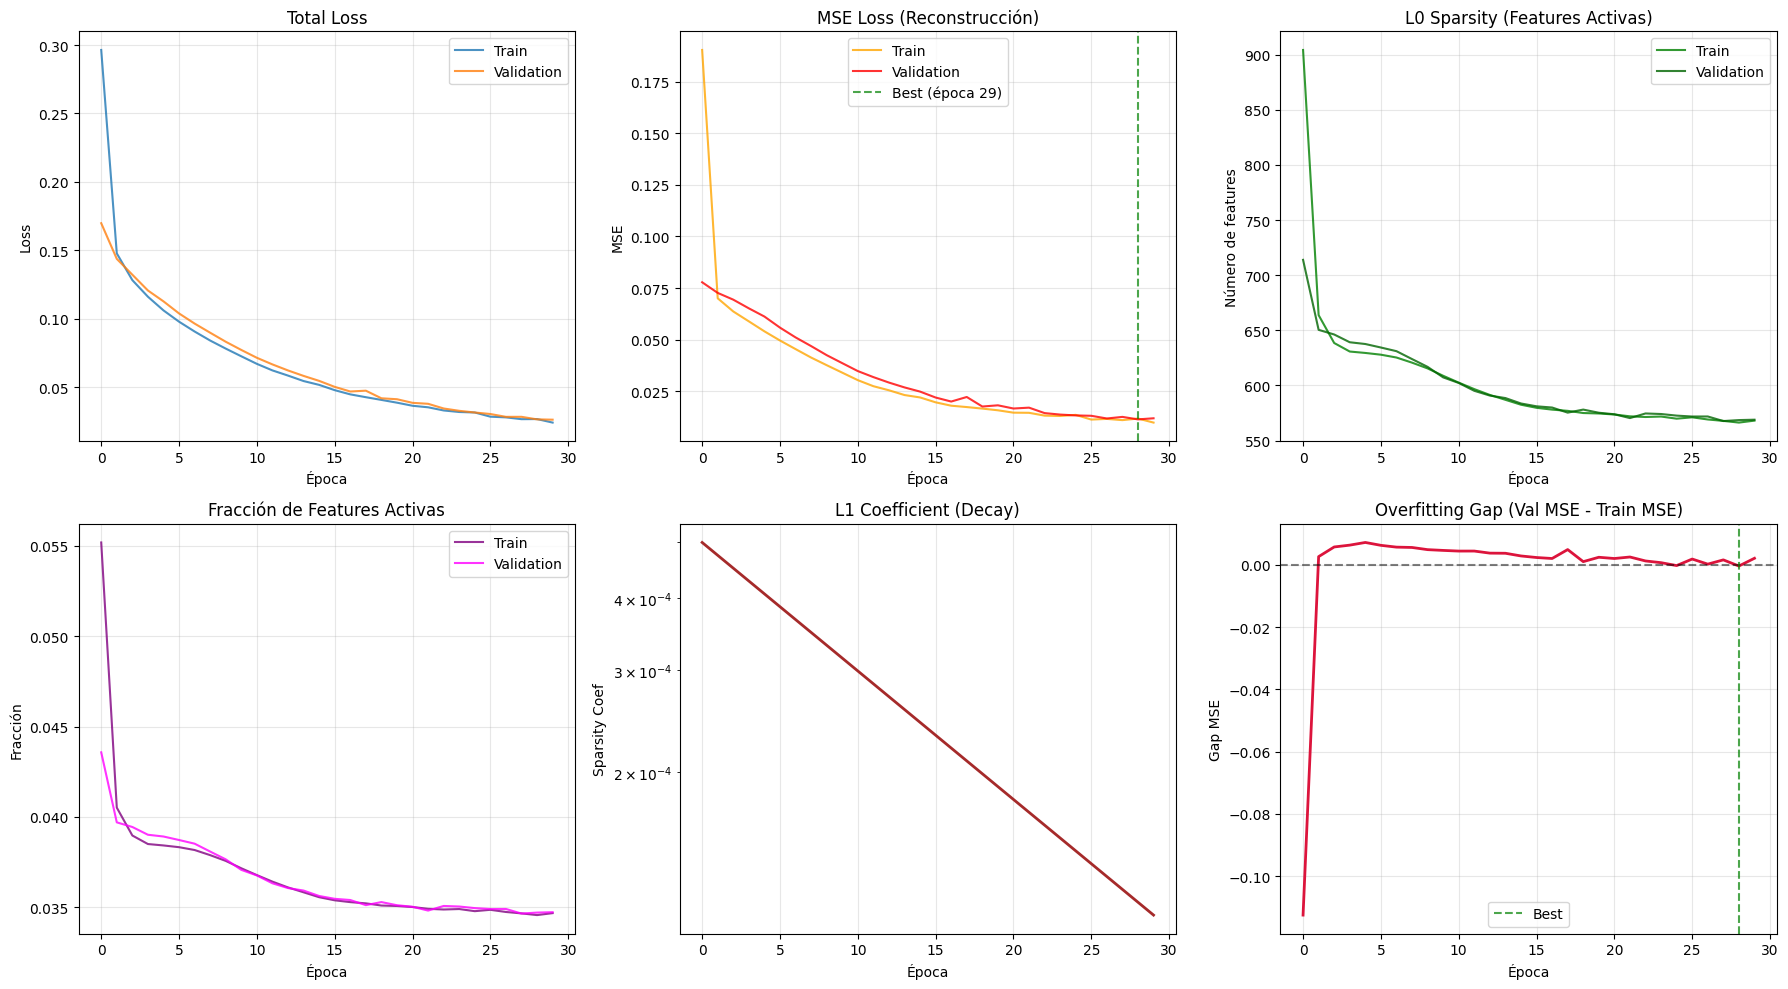


 ✓ Gráficas guardadas exitosamente


In [15]:
# Gráficas de pérdidas (Train vs Validation) + L1 Decay
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Total loss
axes[0, 0].plot(history['train_total_loss'], label='Train', alpha=0.8)
axes[0, 0].plot(history['val_total_loss'], label='Validation', alpha=0.8)
axes[0, 0].set_title('Total Loss')
axes[0, 0].set_xlabel('Época')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MSE loss
axes[0, 1].plot(history['train_mse_loss'], label='Train', color='orange', alpha=0.8)
axes[0, 1].plot(history['val_mse_loss'], label='Validation', color='red', alpha=0.8)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[0, 1].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best (época {best_epoch})')
axes[0, 1].set_title('MSE Loss (Reconstrucción)')
axes[0, 1].set_xlabel('Época')
axes[0, 1].set_ylabel('MSE')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# L0 sparsity
axes[0, 2].plot(history['train_l0_sparsity'], label='Train', color='green', alpha=0.8)
axes[0, 2].plot(history['val_l0_sparsity'], label='Validation', color='darkgreen', alpha=0.8)
axes[0, 2].set_title('L0 Sparsity (Features Activas)')
axes[0, 2].set_xlabel('Época')
axes[0, 2].set_ylabel('Número de features')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Fraction active
axes[1, 0].plot(history['train_fraction_active'], label='Train', color='purple', alpha=0.8)
axes[1, 0].plot(history['val_fraction_active'], label='Validation', color='magenta', alpha=0.8)
axes[1, 0].set_title('Fracción de Features Activas')
axes[1, 0].set_xlabel('Época')
axes[1, 0].set_ylabel('Fracción')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Sparsity Coefficient (L1 Decay)
axes[1, 1].plot(history['sparsity_coef_history'], color='brown', linewidth=2)
axes[1, 1].set_title('L1 Coefficient (Decay)')
axes[1, 1].set_xlabel('Época')
axes[1, 1].set_ylabel('Sparsity Coef')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# Train vs Val MSE Gap
mse_gap = [v - t for v, t in zip(history['val_mse_loss'], history['train_mse_loss'])]
axes[1, 2].plot(mse_gap, color='crimson', linewidth=2)
axes[1, 2].axhline(0, color='black', linestyle='--', alpha=0.5)
if CONFIG['early_stopping'] and best_epoch > 0:
    axes[1, 2].axvline(best_epoch - 1, color='green', linestyle='--', alpha=0.7, label=f'Best')
axes[1, 2].set_title('Overfitting Gap (Val MSE - Train MSE)')
axes[1, 2].set_xlabel('Época')
axes[1, 2].set_ylabel('Gap MSE')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CONFIG['plots_dir'] / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print(' ✓ Gráficas guardadas exitosamente')

print('='*50)

## 9. Análisis de Activaciones

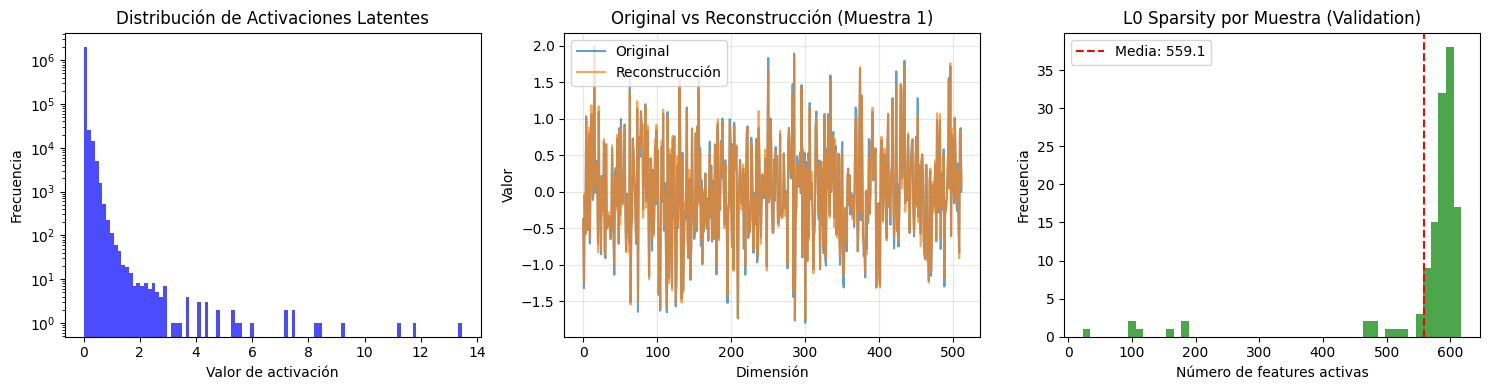


 ESTADÍSTICAS DE ACTIVACIONES
           Métrica  Valor
       L0 Promedio  559.1
        Hidden Dim  16384
   Fracción Activa  3.41%
MSE Reconstrucción 0.0127


In [16]:
# Obtener un batch de validación para análisis
model.eval()
sample_batch = next(iter(val_loader)).to(device)

with torch.no_grad():
    reconstruction, hidden = model(sample_batch)

# Convertir a numpy
hidden_np = hidden.cpu().numpy()
original_np = sample_batch.cpu().numpy()
recon_np = reconstruction.cpu().numpy()

# Visualizar distribución de activaciones
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma de activaciones latentes
axes[0].hist(hidden_np.flatten(), bins=100, alpha=0.7, color='blue')
axes[0].set_title('Distribución de Activaciones Latentes')
axes[0].set_xlabel('Valor de activación')
axes[0].set_ylabel('Frecuencia')
axes[0].set_yscale('log')

# Comparación original vs reconstrucción (primera muestra)
axes[1].plot(original_np[0], label='Original', alpha=0.7)
axes[1].plot(recon_np[0], label='Reconstrucción', alpha=0.7)
axes[1].set_title('Original vs Reconstrucción (Muestra 1)')
axes[1].set_xlabel('Dimensión')
axes[1].set_ylabel('Valor')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Sparsity por muestra
l0_per_sample = (hidden_np > 0).sum(axis=1)
axes[2].hist(l0_per_sample, bins=50, alpha=0.7, color='green')
axes[2].set_title('L0 Sparsity por Muestra (Validation)')
axes[2].set_xlabel('Número de features activas')
axes[2].set_ylabel('Frecuencia')
axes[2].axvline(l0_per_sample.mean(), color='red', linestyle='--', 
                label=f'Media: {l0_per_sample.mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.savefig(CONFIG['plots_dir'] / 'activations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Estadísticas con formato profesional  
stats_df = pd.DataFrame({
    'Métrica': [
        'L0 Promedio',
        'Hidden Dim',
        'Fracción Activa',
        'MSE Reconstrucción'
    ],
    'Valor': [
        f"{l0_per_sample.mean():.1f}",
        f"{CONFIG['hidden_dim']}",
        f"{(hidden_np > 0).mean():.2%}",
        f"{F.mse_loss(reconstruction, sample_batch).item():.4f}"
    ]
})
print('\n' + '='*50)
print(' ESTADÍSTICAS DE ACTIVACIONES')
print('='*50)
print(stats_df.to_string(index=False))
print('='*50)

## 10. Métricas de Calidad del Modelo

Evaluamos la calidad del SAE con múltiples métricas:
- **MSE**: Error de reconstrucción
- **Explained Variance**: % de varianza capturada
- **Cosine Similarity**: Similitud direccional entre original y reconstrucción
- **Dead Neurons**: Features que nunca se activan
- **Sparsity**: L0 promedio y distribución

In [17]:
def evaluate_model_quality(model, dataloader, device):
    """
    Evalúa la calidad del SAE con múltiples métricas
    """
    model.eval()
    
    all_originals = []
    all_reconstructions = []
    all_hiddens = []
    
    print(' Evaluando calidad del modelo...\n')
    
    # Recolectar todas las predicciones
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluando'):
            x = batch.to(device)
            reconstruction, hidden = model(x)
            
            all_originals.append(x.cpu().numpy())
            all_reconstructions.append(reconstruction.cpu().numpy())
            all_hiddens.append(hidden.cpu().numpy())
    
    # Concatenar todos los batches
    originals = np.concatenate(all_originals, axis=0)
    reconstructions = np.concatenate(all_reconstructions, axis=0)
    hiddens = np.concatenate(all_hiddens, axis=0)
    
    metrics = {}
    
    # 1. MSE (Mean Squared Error)
    mse = np.mean((originals - reconstructions) ** 2)
    metrics['MSE'] = mse
    
    # 2. MAE (Mean Absolute Error)
    mae = np.mean(np.abs(originals - reconstructions))
    metrics['MAE'] = mae
    
    # 3. Explained Variance
    var_original = np.var(originals)
    var_residual = np.var(originals - reconstructions)
    explained_var = 1 - (var_residual / var_original)
    metrics['Explained_Variance'] = explained_var
    
    # 4. Cosine Similarity (promedio)
    # Normalizar vectores
    orig_norm = originals / (np.linalg.norm(originals, axis=1, keepdims=True) + 1e-8)
    recon_norm = reconstructions / (np.linalg.norm(reconstructions, axis=1, keepdims=True) + 1e-8)
    cosine_sim = np.sum(orig_norm * recon_norm, axis=1).mean()
    metrics['Cosine_Similarity'] = cosine_sim
    
    # 5. L0 Sparsity (features activas)
    l0_per_sample = (hiddens > 0).sum(axis=1)
    metrics['L0_mean'] = l0_per_sample.mean()
    metrics['L0_std'] = l0_per_sample.std()
    metrics['L0_min'] = l0_per_sample.min()
    metrics['L0_max'] = l0_per_sample.max()
    
    # 6. Fracción de features activas
    fraction_active = (hiddens > 0).mean()
    metrics['Fraction_Active'] = fraction_active
    
    # 7. Dead Neurons (nunca se activan)
    neuron_activations = (hiddens > 0).sum(axis=0)
    dead_neurons = (neuron_activations == 0).sum()
    metrics['Dead_Neurons'] = dead_neurons
    metrics['Dead_Neurons_Fraction'] = dead_neurons / hiddens.shape[1]
    
    # 8. L1 Norm (promedio de activaciones)
    l1_norm = np.abs(hiddens).mean()
    metrics['L1_Norm'] = l1_norm
    
    # 9. Max Activation
    max_activation = hiddens.max()
    metrics['Max_Activation'] = max_activation
    
    # 10. Reconstruction SNR (Signal-to-Noise Ratio)
    signal_power = np.mean(originals ** 2)
    noise_power = np.mean((originals - reconstructions) ** 2)
    snr = 10 * np.log10(signal_power / (noise_power + 1e-8))
    metrics['SNR_dB'] = snr
    
    return metrics, (originals, reconstructions, hiddens)

# Evaluar el modelo en el conjunto de VALIDACIÓN
print(' Evaluando en conjunto de VALIDACIÓN:')
metrics, (originals, reconstructions, hiddens) = evaluate_model_quality(model, val_loader, device)

 Evaluando en conjunto de VALIDACIÓN:
 Evaluando calidad del modelo...



Evaluando: 100%|██████████| 93/93 [00:00<00:00, 163.69it/s]


In [18]:
# Tabla de reconstrucción
recon_metrics = pd.DataFrame({
    'Métrica': ['MSE', 'MAE', 'Explained Variance', 'Cosine Similarity', 'SNR (dB)'],
    'Valor': [
        f"{metrics['MSE']:.6f}",
        f"{metrics['MAE']:.6f}",
        f"{metrics['Explained_Variance']:.2%}",
        f"{metrics['Cosine_Similarity']:.4f}",
        f"{metrics['SNR_dB']:.2f}"
    ]
})

# Tabla de sparsity
sparsity_metrics = pd.DataFrame({
    'Métrica': ['L0 Media', 'L0 Std', 'L0 Rango', 'Fracción Activa', 'L1 Norm', 'Max Activation'],
    'Valor': [
        f"{metrics['L0_mean']:.1f}",
        f"{metrics['L0_std']:.1f}",
        f"[{metrics['L0_min']:.0f}, {metrics['L0_max']:.0f}]",
        f"{metrics['Fraction_Active']:.3%}",
        f"{metrics['L1_Norm']:.4f}",
        f"{metrics['Max_Activation']:.4f}"
    ]
})

# Tabla de dead neurons
dead_metrics = pd.DataFrame({
    'Métrica': ['Dead Neurons', 'Total Neurons', 'Porcentaje'],
    'Valor': [
        f"{metrics['Dead_Neurons']}",
        f"{CONFIG['hidden_dim']}",
        f"{metrics['Dead_Neurons_Fraction']:.2%}"
    ]
})

print('\n' + '='*70)
print(' MÉTRICAS DE CALIDAD DEL MODELO')
print('='*70)

print('\nCalidad de Reconstrucción:')
print(recon_metrics.to_string(index=False))

print('\nSparsity:')
print(sparsity_metrics.to_string(index=False))

print('\nDead Neurons:')
print(dead_metrics.to_string(index=False))

print('\n' + '='*70)

# Interpretación automática
interpretacion = []

if metrics['Explained_Variance'] > 0.95:
    interpretacion.append('✓ Excelente reconstrucción (>95% varianza explicada)')
elif metrics['Explained_Variance'] > 0.85:
    interpretacion.append('✓ Buena reconstrucción (>85% varianza explicada)')
else:
    interpretacion.append('⚠ Reconstrucción mejorable (<85% varianza explicada)')

if metrics['Dead_Neurons_Fraction'] > 0.30:
    interpretacion.append('⚠ Muchas neuronas muertas (>30%) - considera reducir hidden_dim')
elif metrics['Dead_Neurons_Fraction'] < 0.10:
    interpretacion.append('✓ Pocas neuronas muertas (<10%)')
else:
    interpretacion.append('✓ Neuronas muertas aceptables (<30%)')

if metrics['Fraction_Active'] > 0.15:
    interpretacion.append('⚠ Sparsity mejorable (>15% features activas)')
else:
    interpretacion.append('✓ Buena sparsity (<15% features activas)')

interp_df = pd.DataFrame({'Interpretación': interpretacion})
print('\nInterpretación:')
print(interp_df.to_string(index=False, header=False))


 MÉTRICAS DE CALIDAD DEL MODELO

Calidad de Reconstrucción:
           Métrica    Valor
               MSE 0.011925
               MAE 0.084941
Explained Variance   98.60%
 Cosine Similarity   0.9917
          SNR (dB)    18.53

Sparsity:
        Métrica      Valor
       L0 Media      569.0
         L0 Std      100.6
       L0 Rango [23, 2051]
Fracción Activa     3.473%
        L1 Norm     0.0077
 Max Activation    17.2894

Dead Neurons:
      Métrica  Valor
 Dead Neurons   7891
Total Neurons  16384
   Porcentaje 48.16%


Interpretación:
           ✓ Excelente reconstrucción (>95% varianza explicada)
⚠ Muchas neuronas muertas (>30%) - considera reducir hidden_dim
                       ✓ Buena sparsity (<15% features activas)


## 11. Resumen Final

In [19]:
# Resumen final completo
print('\n' + '='*70)
print(' RESUMEN FINAL DEL ENTRENAMIENTO')
print('='*70)

# Arquitectura
arch_summary = pd.DataFrame({
    'Componente': ['Input', 'Hidden', 'Parámetros'],
    'Valor': [
        f"{CONFIG['input_dim']}",
        f"{CONFIG['hidden_dim']} ({CONFIG['hidden_dim']/CONFIG['input_dim']:.1f}x)",
        f"{num_params:,}"
    ]
})
print('\nArquitectura:')
print(arch_summary.to_string(index=False))

# Datos
data_summary = pd.DataFrame({
    'Conjunto': ['Train', 'Validation', 'Total'],
    'Muestras': [
        f"{len(train_dataset):,}",
        f"{len(val_dataset):,}",
        f"{len(full_dataset):,}"
    ]
})
print('\nDatos:')
print(data_summary.to_string(index=False))

# Métricas finales
final_summary = pd.DataFrame({
    'Métrica': ['Train Loss', 'Val Loss', 'Train MSE', 'Val MSE', 'Train L0', 'Val L0'],
    'Valor': [
        f"{history['train_total_loss'][-1]:.4f}",
        f"{history['val_total_loss'][-1]:.4f}",
        f"{history['train_mse_loss'][-1]:.4f}",
        f"{history['val_mse_loss'][-1]:.4f}",
        f"{history['train_l0_sparsity'][-1]:.1f}",
        f"{history['val_l0_sparsity'][-1]:.1f}"
    ]
})
print('\nMétricas Finales:')
print(final_summary.to_string(index=False))

# Archivos
files_summary = pd.DataFrame({
    'Tipo': ['Modelo', 'Gráficas', 'Análisis'],
    'Ubicación': [
        str(checkpoint_path),
        str(CONFIG['plots_dir'] / 'training_curves.png'),
        str(CONFIG['plots_dir'] / 'activations_analysis.png')
    ]
})
print('\nArchivos Guardados:')
print(files_summary.to_string(index=False))

print('\n' + '='*70)
print(' ✓ ENTRENAMIENTO COMPLETADO EXITOSAMENTE')
print('='*70)


 RESUMEN FINAL DEL ENTRENAMIENTO

Arquitectura:
Componente         Valor
     Input           512
    Hidden 16384 (32.0x)
Parámetros    16,794,112

Datos:
  Conjunto Muestras
     Train   47,200
Validation   11,800
     Total   59,000

Métricas Finales:
   Métrica  Valor
Train Loss 0.0241
  Val Loss 0.0262
 Train MSE 0.0098
   Val MSE 0.0119
  Train L0  568.1
    Val L0  569.0

Archivos Guardados:
    Tipo                        Ubicación
  Modelo saved_model\sae_othello_final.pt
Gráficas        plots\training_curves.png
Análisis   plots\activations_analysis.png

 ✓ ENTRENAMIENTO COMPLETADO EXITOSAMENTE
